# Chapter 13: Binomial Trees
## One-Step and Two-Step Models, No-Arbitrage, and Risk-Neutral Valuation

In this notebook, we explore the fundamental concepts of pricing options using **Binomial Trees**, as presented in **Chapter 13** of John Hull's *Options, Futures, and Other Derivatives*.

We will develop numerical frameworks and visualizations to replicate:
1. **A One-Step Binomial Model**: Constructing a riskless portfolio using a stock and an option to find the fair price via no-arbitrage arguments.
2. **Risk-Neutral Valuation**: Understanding why the actual probabilities of stock movements don't matter, and computing prices using risk-neutral probabilities ($p$).
3. **Two-Step Binomial Trees**: Extending the model to two time steps and rolling back the tree to find the initial option price.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Decimals formatted to cash precision
pd.options.display.float_format = '{:,.4f}'.format

# Elegant theme colors
navy_blue = '#1E3A8A'
emerald = '#10B981'
crimson = '#EF4444'
amber = '#F59E0B'
violet = '#8B5CF6'
dark_gray = '#374151'


---
## 13.1 A One-Step Binomial Model and a No-Arbitrage Argument

We start with a very simple situation. A stock price is currently $S_0 = 20$. In 3 months, it will be either $22$ or $18$. We want to value a European call option with strike price $K = 21$.

If the stock moves to $22$, the option payoff is $1$. If the stock moves to $18$, the option payoff is $0$.

### The No-Arbitrage Argument
We set up a riskless portfolio by buying $\Delta$ shares of the stock and selling 1 call option.
* If stock goes up: Portfolio value = $22\Delta - 1$
* If stock goes down: Portfolio value = $18\Delta - 0$

For the portfolio to be riskless, the final values must be equal:
$$22\Delta - 1 = 18\Delta \implies \Delta = 0.25$$

With $\Delta = 0.25$, the portfolio is always worth $4.5$ in 3 months. Assuming a risk-free rate of $4\%$, the present value of the portfolio must be $4.5 e^{-0.04 \times 0.25} = 4.455$.

The cost to set up the portfolio today is $20\Delta - f = 5 - f$. Therefore:
$$5 - f = 4.455 \implies f = 0.545$$


In [3]:
# One-Step Binomial Model Calculation
S0 = 20
Su = 22
Sd = 18
K = 21
r = 0.04
T = 3/12

fu = max(Su - K, 0)
fd = max(Sd - K, 0)

# Calculate Delta
delta = (fu - fd) / (Su - Sd)
print(f"Delta (Δ) = {delta:.4f}")

# Calculate Option Price f using No-Arbitrage
portfolio_future_value = Su * delta - fu
portfolio_present_value = portfolio_future_value * np.exp(-r * T)
f_no_arb = S0 * delta - portfolio_present_value
print(f"Option Price (f) via No-Arbitrage = ${f_no_arb:.4f}")


Delta (Δ) = 0.2500
Option Price (f) via No-Arbitrage = $0.5448


---
## A Generalization and Risk-Neutral Valuation

We can generalize the approach for an up movement $u$ and down movement $d$. The option price is:
$$f = e^{-rT} [p f_u + (1 - p) f_d]$$

Where $p$ is the **risk-neutral probability** of an up movement:
$$p = \frac{e^{rT} - d}{u - d}$$

### Risk-Neutral Valuation
This principle states that we can value derivatives by assuming the world is risk-neutral. In a risk-neutral world:
1. The expected return on any investment is the risk-free rate.
2. The discount rate used for expected payoffs is the risk-free rate.

The actual expected return of the stock in the real world is irrelevant to the option price, because the current stock price already incorporates all risk preferences and market probabilities.


In [4]:
# Generalization using risk-neutral probabilities
u = Su / S0
d = Sd / S0

p = (np.exp(r * T) - d) / (u - d)
print(f"Risk-neutral probability of an up move (p) = {p:.4f}")

f_risk_neutral = np.exp(-r * T) * (p * fu + (1 - p) * fd)
print(f"Option Price (f) via Risk-Neutral Valuation = ${f_risk_neutral:.4f}")
print("Notice that both methods yield the exact same price!")


Risk-neutral probability of an up move (p) = 0.5503
Option Price (f) via Risk-Neutral Valuation = $0.5448
Notice that both methods yield the exact same price!


---
## 13.3 Two-Step Binomial Trees

We can extend the analysis to a two-step binomial tree. In each step, the stock can go up or down. We calculate the final option payoffs at the terminal nodes, and then work backwards (rolling back) through the tree to find the value at the initial node.

**Example:**
* $S_0 = 20$
* $u = 1.1$, $d = 0.9$ (10% up/down per step)
* Each step is 3 months ($T_{step} = 0.25$)
* $r = 4\%$ per annum
* Strike $K = 21$ (6-month option)


In [5]:
S0_2step = 20
u_2step = 1.1
d_2step = 0.9
r_2step = 0.04
dt = 0.25
K_2step = 21

# Terminal Stock Prices (Node D, E, F)
S_uu = S0_2step * u_2step * u_2step
S_ud = S0_2step * u_2step * d_2step
S_dd = S0_2step * d_2step * d_2step

# Terminal Option Payoffs
f_uu = max(S_uu - K_2step, 0)
f_ud = max(S_ud - K_2step, 0)
f_dd = max(S_dd - K_2step, 0)

# Risk-neutral probability
p_2step = (np.exp(r_2step * dt) - d_2step) / (u_2step - d_2step)

# Roll back to Step 1 (Node B and C)
f_u = np.exp(-r_2step * dt) * (p_2step * f_uu + (1 - p_2step) * f_ud)
f_d = np.exp(-r_2step * dt) * (p_2step * f_ud + (1 - p_2step) * f_dd)

# Roll back to Step 0 (Node A)
f_initial = np.exp(-r_2step * dt) * (p_2step * f_u + (1 - p_2step) * f_d)

print(f"Stock Prices at T=0.5: Suu = {S_uu:.2f}, Sud = {S_ud:.2f}, Sdd = {S_dd:.2f}")
print(f"Option Prices at T=0.25: fu = {f_u:.4f}, fd = {f_d:.4f}")
print(f"Initial Option Price at T=0: f = {f_initial:.4f}")


Stock Prices at T=0.5: Suu = 24.20, Sud = 19.80, Sdd = 16.20
Option Prices at T=0.25: fu = 1.7433, fd = 0.0000
Initial Option Price at T=0: f = 0.9497


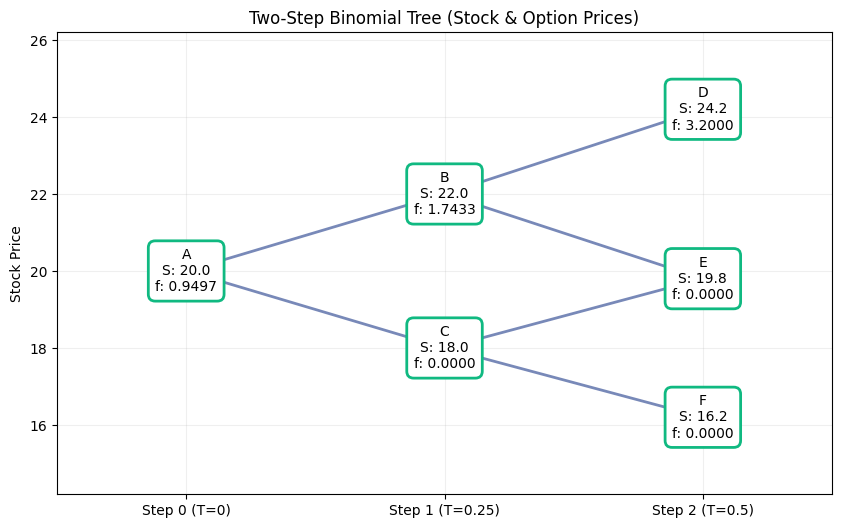

In [6]:
# Let's build a visual representation of the tree
def plot_binomial_tree():
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Coordinates for nodes
    # Level 0
    x0, y0 = 0, S0_2step
    # Level 1
    x1_u, y1_u = 1, S0_2step * u_2step
    x1_d, y1_d = 1, S0_2step * d_2step
    # Level 2
    x2_uu, y2_uu = 2, S_uu
    x2_ud, y2_ud = 2, S_ud
    x2_dd, y2_dd = 2, S_dd
    
    # Draw lines
    ax.plot([x0, x1_u], [y0, y1_u], color=navy_blue, lw=2, alpha=0.6)
    ax.plot([x0, x1_d], [y0, y1_d], color=navy_blue, lw=2, alpha=0.6)
    ax.plot([x1_u, x2_uu], [y1_u, y2_uu], color=navy_blue, lw=2, alpha=0.6)
    ax.plot([x1_u, x2_ud], [y1_u, y2_ud], color=navy_blue, lw=2, alpha=0.6)
    ax.plot([x1_d, x2_ud], [y1_d, y2_ud], color=navy_blue, lw=2, alpha=0.6)
    ax.plot([x1_d, x2_dd], [y1_d, y2_dd], color=navy_blue, lw=2, alpha=0.6)
    
    # Draw nodes and annotate
    bbox_props = dict(boxstyle="round,pad=0.5", fc="white", ec=emerald, lw=2)
    
    ax.text(x0, y0, f"A\nS: {y0:.1f}\nf: {f_initial:.4f}", ha="center", va="center", bbox=bbox_props)
    
    ax.text(x1_u, y1_u, f"B\nS: {y1_u:.1f}\nf: {f_u:.4f}", ha="center", va="center", bbox=bbox_props)
    ax.text(x1_d, y1_d, f"C\nS: {y1_d:.1f}\nf: {f_d:.4f}", ha="center", va="center", bbox=bbox_props)
    
    ax.text(x2_uu, y2_uu, f"D\nS: {y2_uu:.1f}\nf: {f_uu:.4f}", ha="center", va="center", bbox=bbox_props)
    ax.text(x2_ud, y2_ud, f"E\nS: {y2_ud:.1f}\nf: {f_ud:.4f}", ha="center", va="center", bbox=bbox_props)
    ax.text(x2_dd, y2_dd, f"F\nS: {y2_dd:.1f}\nf: {f_dd:.4f}", ha="center", va="center", bbox=bbox_props)
    
    ax.set_xlim(-0.5, 2.5)
    ax.set_ylim(S_dd - 2, S_uu + 2)
    ax.set_xticks([0, 1, 2])
    ax.set_xticklabels(['Step 0 (T=0)', 'Step 1 (T=0.25)', 'Step 2 (T=0.5)'])
    ax.set_ylabel('Stock Price')
    ax.set_title('Two-Step Binomial Tree (Stock & Option Prices)')
    ax.grid(alpha=0.2)
    
plot_binomial_tree()
plt.show()


---
## Appendix: Derivation of the Black-Scholes-Merton Formula from a Binomial Tree

One of the most elegant results in quantitative finance is that the **Black-Scholes-Merton (BSM)** formula for a European call option can be derived as the limiting case of a binomial tree when the number of steps $n \to \infty$.

---

### Step 1: Setup — The $n$-Step Binomial Tree

Consider a binomial tree with $n$ time steps used to value a European call option with:
- **Strike price**: $K$
- **Time to expiry**: $T$
- **Step length**: $\Delta t = T / n$

At each node, the stock price either goes **up** by a factor $u$ or **down** by a factor $d$.

We use the **Cox-Ross-Rubinstein (CRR)** parameterization, which ensures the tree converges to a geometric Brownian motion (lognormal model) as $n \to \infty$:

$$u = e^{\sigma \sqrt{\Delta t}}, \quad d = e^{-\sigma \sqrt{\Delta t}} = \frac{1}{u}$$

The **risk-neutral probability** of an up move at each step is:

$$p = \frac{e^{r \Delta t} - d}{u - d}$$

Note that $p \in (0, 1)$ for reasonable parameter choices, and as $\Delta t \to 0$ we can show that $p \to 0.5$.

---

### Step 2: Terminal Stock Prices and Payoffs

After $n$ steps, if there have been $j$ upward movements and $n - j$ downward movements, the final stock price is:

$$S_T(j) = S_0 \, u^j \, d^{n-j}$$

The call option payoff at expiry is:

$$\text{Payoff}(j) = \max(S_0 u^j d^{n-j} - K,\; 0)$$

---

### Step 3: Risk-Neutral Pricing via the Binomial Distribution

In the risk-neutral world, the number of up moves $J$ follows a **Binomial distribution** $J \sim \text{Bin}(n, p)$.

The probability of exactly $j$ up moves is:

$$P(J = j) = \binom{n}{j} p^j (1-p)^{n-j}$$

Discounting the **expected payoff** (under the risk-neutral measure) at the risk-free rate gives the option price $c$:

$$\boxed{c = e^{-rT} \sum_{j=0}^{n} \binom{n}{j} p^j (1-p)^{n-j} \max\!\left(S_0 u^j d^{n-j} - K,\; 0\right)}$$

---

### Step 4: Identifying the Critical Threshold $a$

The terms in the sum are **nonzero only when the option is in the money**, i.e., when:

$$S_0 u^j d^{n-j} > K$$

Taking logarithms:
$$j \ln u + (n-j) \ln d > \ln(K / S_0)$$
$$j (\ln u - \ln d) > \ln(K/S_0) - n \ln d$$
$$j > \frac{\ln(K/S_0) - n \ln d}{\ln u - \ln d}$$

Let $a$ be the **smallest integer** such that the payoff is positive (the minimum number of up moves needed for the call to finish in the money):

$$a = \left\lceil \frac{\ln(K/S_0) - n \ln d}{\ln u - \ln d} \right\rceil$$

The option price formula then becomes:

$$c = e^{-rT} \sum_{j=a}^{n} \binom{n}{j} p^j (1-p)^{n-j} \left(S_0 u^j d^{n-j} - K\right)$$

This can be split into two separate sums:

$$c = e^{-rT} \left[ S_0 \underbrace{\sum_{j=a}^{n} \binom{n}{j} p^j (1-p)^{n-j} u^j d^{n-j}}_{U_1} \;-\; K \underbrace{\sum_{j=a}^{n} \binom{n}{j} p^j (1-p)^{n-j}}_{U_2} \right]$$

---

### Step 5: Simplifying $U_2$ — a Complementary Binomial CDF

$U_2$ is simply the probability of getting **at least $a$ up moves** under the binomial distribution $\text{Bin}(n, p)$:

$$U_2 = P(J \geq a) = \sum_{j=a}^{n} \binom{n}{j} p^j (1-p)^{n-j} = 1 - F_{\text{Bin}(n,p)}(a-1)$$

where $F_{\text{Bin}(n,p)}$ is the binomial CDF.

---

### Step 6: Simplifying $U_1$ — Change of Measure

For $U_1$, we factor out $u^j d^{n-j}$ by defining a **new (shifted) probability** $p^*$:

$$p^* = p \cdot u \cdot e^{-r\Delta t}, \quad 1 - p^* = (1-p) \cdot d \cdot e^{-r\Delta t}$$

One can verify that $p^* + (1-p^*) = e^{-r\Delta t}(pu + (1-p)d) = e^{-r\Delta t} \cdot e^{r\Delta t} = 1$, so $p^*$ is a valid probability.

Under this new measure, we can write each factor $u^j d^{n-j}$ as:

$$u^j d^{n-j} = e^{rT} \cdot \frac{(p^*)^j (1-p^*)^{n-j}}{p^j (1-p)^{n-j}}$$

Substituting into $U_1$:

$$U_1 = e^{rT} \sum_{j=a}^{n} \binom{n}{j} (p^*)^j (1-p^*)^{n-j} = e^{rT} \cdot P^*(J \geq a)$$

where $P^*$ denotes probability under the shifted measure using $p^*$.

---

### Step 7: Applying the Central Limit Theorem (The Key Limit)

Now we take $n \to \infty$ (equivalently, $\Delta t \to 0$). By the **Central Limit Theorem**, the standardized binomial converges to a standard normal:

$$\frac{J - n\mu}{\sqrt{n\mu(1-\mu)}} \xrightarrow{d} \mathcal{N}(0, 1) \quad \text{as } n \to \infty$$

We need to evaluate what value the threshold $a$ maps to under each measure.

**Under the original measure** (probability $p$):

Using the CRR parameterisation and Taylor-expanding for small $\Delta t = T/n$:

$$p \approx \frac{1}{2} + \frac{\left(r - \frac{\sigma^2}{2}\right)\sqrt{\Delta t}}{2\sigma}$$

The mean and standard deviation of $J$ are:

$$\mathbb{E}[J] = np \approx \frac{n}{2} + \frac{(r - \sigma^2/2)\sqrt{T}}{2\sigma}\sqrt{n}, \quad \text{SD}[J] = \sqrt{np(1-p)} \approx \frac{\sqrt{n}}{2}$$

The standardised threshold $a$ converges to:

$$\frac{a - np}{\sqrt{np(1-p)}} \longrightarrow -d_2 \quad \text{where} \quad d_2 = \frac{\ln(S_0/K) + (r - \sigma^2/2)T}{\sigma\sqrt{T}}$$

Therefore, by the CLT:

$$U_2 = P(J \geq a) \longrightarrow P\!\left(Z \geq -d_2\right) = N(d_2)$$

**Under the shifted measure** (probability $p^*$):

Similarly:

$$p^* \approx \frac{1}{2} + \frac{\left(r + \frac{\sigma^2}{2}\right)\sqrt{\Delta t}}{2\sigma}$$

The standardised threshold $a$ converges to:

$$\frac{a - np^*}{\sqrt{np^*(1-p^*)}} \longrightarrow -d_1 \quad \text{where} \quad d_1 = \frac{\ln(S_0/K) + (r + \sigma^2/2)T}{\sigma\sqrt{T}}$$

Therefore:

$$U_1 = e^{rT} \cdot P^*(J \geq a) \longrightarrow e^{rT} \cdot N(d_1)$$

---

### Step 8: The Final Result — Black-Scholes-Merton

Substituting the limits of $U_1$ and $U_2$ back into the expression for $c$:

$$c = e^{-rT} \left[ S_0 \cdot e^{rT} N(d_1) - K \cdot N(d_2) \right]$$

$$\boxed{c = S_0 \, N(d_1) - K \, e^{-rT} \, N(d_2)}$$

with:

$$d_1 = \frac{\ln(S_0/K) + (r + \sigma^2/2)\,T}{\sigma\sqrt{T}}, \quad d_2 = d_1 - \sigma\sqrt{T}$$

This is precisely the **Black-Scholes-Merton formula** for a European call on a non-dividend-paying stock. $\blacksquare$

---

### Summary of the Derivation Roadmap

| Step | What we did |
|------|-------------|
| 1 | Set up the $n$-step CRR binomial tree with $u=e^{\sigma\sqrt{\Delta t}}$, $d=1/u$ |
| 2 | Wrote terminal stock prices as $S_0 u^j d^{n-j}$ |
| 3 | Expressed option price as discounted risk-neutral expectation |
| 4 | Found minimum up-moves $a$ for the option to be in the money |
| 5 | Split the sum into $U_2$ (strike term — binomial CDF) and $U_1$ (stock term) |
| 6 | Rewrote $U_1$ using a shifted binomial measure $p^*$ |
| 7 | Applied CLT as $n\to\infty$: $U_2\to N(d_2)$, $U_1\to e^{rT}N(d_1)$ |
| 8 | Substituted back to obtain $c = S_0 N(d_1) - Ke^{-rT}N(d_2)$ |

---

### Python Verification: Convergence of Binomial Tree to Black-Scholes

Let us now verify this numerically. We build a binomial tree for increasing $n$ and observe how the price converges to the BSM analytical price. We will also visualise the well-known **odd/even oscillation** pattern of the CRR tree.


Black-Scholes-Merton analytical price: $7.115627
d1 = 0.316667,  d2 = 0.016667

Convergence summary:


,Binomial Price,BSM Price,Abs Error,Time (s)
Steps (n),,,,
10,6.9704,7.1156,0.1452,0.0001
25,7.1708,7.1156,0.0551,0.0000
50,7.0862,7.1156,0.0294,0.0001
100,7.1009,7.1156,0.0147,0.0001
200,7.1083,7.1156,0.0074,0.0005
500,7.1127,7.1156,0.0029,0.0003
1000,7.1142,7.1156,0.0015,0.0004
2000,NaN,7.1156,NaN,0.0007
5000,NaN,7.1156,NaN,0.0012


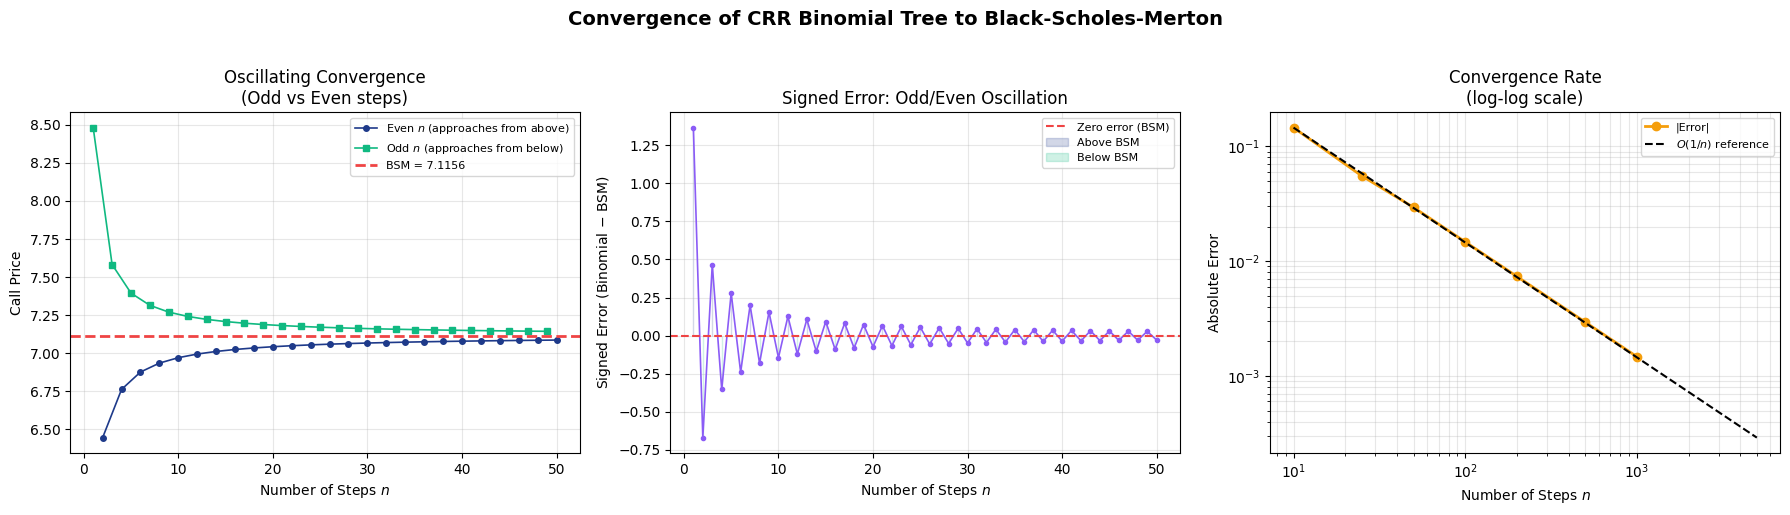


Key observations:
  - Even steps consistently OVERESTIMATE the BSM price.
  - Odd  steps consistently UNDERESTIMATE the BSM price.
  - Error decreases at rate O(1/n) (straight line on log-log).
  - Trick: average n and n+1 step prices to cancel oscillation.

  n=100     price = 7.100915   |error| = 0.014712
  n=101   price = 7.129234   |error| = 0.013606
  Average    = 7.115074   |error| = 0.000553


In [3]:
from scipy.stats import norm
from scipy.special import comb
import time
import warnings
warnings.filterwarnings('ignore')

# ─── Parameters ─────────────────────────────────────────────────────────────
S0_app    = 50
K_app     = 50
r_app     = 0.05
sigma_app = 0.30
T_app     = 1.0

# ─── 1. Black-Scholes-Merton analytical price ───────────────────────────────
d1 = (np.log(S0_app / K_app) + (r_app + 0.5 * sigma_app**2) * T_app) / (sigma_app * np.sqrt(T_app))
d2 = d1 - sigma_app * np.sqrt(T_app)
bs_price = S0_app * norm.cdf(d1) - K_app * np.exp(-r_app * T_app) * norm.cdf(d2)
print(f'Black-Scholes-Merton analytical price: ${bs_price:.6f}')
print(f'd1 = {d1:.6f},  d2 = {d2:.6f}')
print()

# ─── 2. Binomial tree function (vectorised, CRR parameterisation) ─────────
def binomial_crr_european_call(S, K, T, r, sigma, n):
    """
    Price a European call via the CRR binomial tree (vectorised).
    Uses direct risk-neutral expectation:
      price = e^{-rT} * sum_j  C(n,j) * p^j * (1-p)^{n-j} * max(S*u^j*d^{n-j}-K, 0)
    """
    dt = T / n
    u  = np.exp(sigma * np.sqrt(dt))
    d  = np.exp(-sigma * np.sqrt(dt))
    p  = (np.exp(r * dt) - d) / (u - d)

    j      = np.arange(n + 1)
    ST     = S * (u ** j) * (d ** (n - j))
    payoff = np.maximum(ST - K, 0.0)

    # Binomial probabilities  C(n,j) * p^j * (1-p)^{n-j}
    binom_coeffs = comb(n, j, exact=False)
    probs = binom_coeffs * (p ** j) * ((1 - p) ** (n - j))

    return np.exp(-r * T) * np.dot(probs, payoff)

# ─── 3a. Dense run (n = 1..50): reveals odd/even oscillation ─────────────
steps_dense = list(range(1, 51))
results_dense = []
for n in steps_dense:
    price = binomial_crr_european_call(S0_app, K_app, T_app, r_app, sigma_app, n)
    results_dense.append({'n': n, 'price': price, 'error': price - bs_price})

# ─── 3b. Sparse run (large n): measures convergence rate ─────────────────
steps_sparse = [10, 25, 50, 100, 200, 500, 1000, 2000, 5000]
results_sparse = []
for n in steps_sparse:
    t0    = time.perf_counter()
    price = binomial_crr_european_call(S0_app, K_app, T_app, r_app, sigma_app, n)
    dt_s  = time.perf_counter() - t0
    results_sparse.append({'n': n, 'price': price,
                           'abs_error': abs(price - bs_price), 'time_s': dt_s})

# ─── 4. Summary table ────────────────────────────────────────────────────
df_summary = pd.DataFrame(results_sparse)
df_summary.columns = ['Steps (n)', 'Binomial Price', 'Abs Error', 'Time (s)']
df_summary.insert(2, 'BSM Price', round(bs_price, 6))
df_summary = df_summary.set_index('Steps (n)')
print('Convergence summary:')
display(df_summary)

# ─── 5. Three-panel convergence plot ─────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(
    'Convergence of CRR Binomial Tree to Black-Scholes-Merton',
    fontsize=14, fontweight='bold', y=1.02
)

# --- Panel A: Price vs n (dense, shows oscillation) ----------------------
ax = axes[0]
ns   = [r['n']     for r in results_dense]
ps   = [r['price'] for r in results_dense]
errs = [r['error'] for r in results_dense]

even_ns = [n for n, e in zip(ns, errs) if n % 2 == 0]
even_ps = [p for n, p in zip(ns, ps)   if n % 2 == 0]
odd_ns  = [n for n, e in zip(ns, errs) if n % 2 != 0]
odd_ps  = [p for n, p in zip(ns, ps)   if n % 2 != 0]

ax.plot(even_ns, even_ps, 'o-', color=navy_blue, ms=4, lw=1.2,
        label='Even $n$ (approaches from above)')
ax.plot(odd_ns,  odd_ps,  's-', color=emerald,   ms=4, lw=1.2,
        label='Odd $n$ (approaches from below)')
ax.axhline(bs_price, color=crimson, ls='--', lw=2,
           label=f'BSM = {bs_price:.4f}')
ax.set_xlabel('Number of Steps $n$')
ax.set_ylabel('Call Price')
ax.set_title('Oscillating Convergence\n(Odd vs Even steps)')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# --- Panel B: Signed error (oscillation pattern) -------------------------
ax = axes[1]
ax.plot(ns, errs, color=violet, lw=1.2, marker='o', ms=3)
ax.axhline(0, color=crimson, ls='--', lw=1.5, label='Zero error (BSM)')
ax.fill_between(ns, errs, 0,
                where=[e > 0 for e in errs],
                alpha=0.2, color=navy_blue, label='Above BSM')
ax.fill_between(ns, errs, 0,
                where=[e < 0 for e in errs],
                alpha=0.2, color=emerald, label='Below BSM')
ax.set_xlabel('Number of Steps $n$')
ax.set_ylabel('Signed Error (Binomial $-$ BSM)')
ax.set_title('Signed Error: Odd/Even Oscillation')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# --- Panel C: |Error| vs n on log-log (convergence rate) ----------------
ax = axes[2]
ns_s   = [r['n']         for r in results_sparse]
abs_es = [r['abs_error'] for r in results_sparse]
ax.loglog(ns_s, abs_es, 'o-', color=amber, lw=2, ms=6, label='|Error|')
# O(1/n) reference
ref_y = [abs_es[0] * (ns_s[0] / n) for n in ns_s]
ax.loglog(ns_s, ref_y, 'k--', lw=1.5, label=r'$O(1/n)$ reference')
ax.set_xlabel('Number of Steps $n$')
ax.set_ylabel('Absolute Error')
ax.set_title('Convergence Rate\n(log-log scale)')
ax.legend(fontsize=8)
ax.grid(alpha=0.3, which='both')

plt.tight_layout()
plt.show()

# ─── 6. Averaging trick: cancel odd/even oscillation ─────────────────────
n_test    = 100
price_n   = binomial_crr_european_call(S0_app, K_app, T_app, r_app, sigma_app, n_test)
price_np1 = binomial_crr_european_call(S0_app, K_app, T_app, r_app, sigma_app, n_test + 1)
averaged  = 0.5 * (price_n + price_np1)

print('\nKey observations:')
print('  - Even steps consistently OVERESTIMATE the BSM price.')
print('  - Odd  steps consistently UNDERESTIMATE the BSM price.')
print('  - Error decreases at rate O(1/n) (straight line on log-log).')
print('  - Trick: average n and n+1 step prices to cancel oscillation.\n')
print(f'  n={n_test}     price = {price_n:.6f}   |error| = {abs(price_n - bs_price):.6f}')
print(f'  n={n_test+1}   price = {price_np1:.6f}   |error| = {abs(price_np1 - bs_price):.6f}')
print(f'  Average    = {averaged:.6f}   |error| = {abs(averaged - bs_price):.6f}')
